In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Open the ROOT file
root_file = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_GUNDAM/data/__ARCHIVE__/uniform_binning.root"
print("Opening ROOT file...")
file = uproot.open(root_file)

Opening ROOT file...



Reading flux histograms...

INTEGRATED FLUX
νμ flux:           4.616345e-06 /POT
ν̄μ flux:           2.699919e-06 /POT
Total (νμ + ν̄μ):   7.316264e-06 /POT
  For MC POT = 7.18e+20: 5.251614e+15 ν/m² = 5.251614e+11 ν/cm²


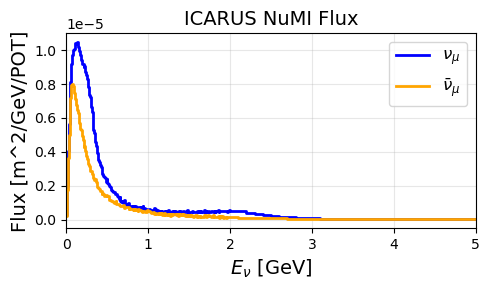

In [3]:
# Read the histograms
print("\nReading flux histograms...")
numu_hist = file["corrected_flux_fhc_numu_BinWidthDivided;1"]
numubar_hist = file["corrected_flux_fhc_numubar_BinWidthDivided;1"]

# Extract bin edges and values
edges_numu = numu_hist.axis().edges()
values_numu = numu_hist.values()

edges_numubar = numubar_hist.axis().edges()
values_numubar = numubar_hist.values()

# Calculate bin centers and widths
bin_centers_numu = (edges_numu[:-1] + edges_numu[1:]) / 2
bin_widths_numu = np.diff(edges_numu)

bin_centers_numubar = (edges_numubar[:-1] + edges_numubar[1:]) / 2
bin_widths_numubar = np.diff(edges_numubar)

# Integrate: sum(flux_per_GeV * bin_width)
integrated_flux_numu = np.sum(values_numu * bin_widths_numu)
integrated_flux_numubar = np.sum(values_numubar * bin_widths_numubar)
integrated_flux_total = integrated_flux_numu + integrated_flux_numubar

print("\n" + "="*70)
print("INTEGRATED FLUX")
print("="*70)
print(f"νμ flux:           {integrated_flux_numu:.6e} /POT")
print(f"ν̄μ flux:           {integrated_flux_numubar:.6e} /POT")
print(f"Total (νμ + ν̄μ):   {integrated_flux_total:.6e} /POT")
print("="*70)

# Integrated flux calculation
MC_POT = 7.78521e+20 #1.471149e20
MC_POT = 7.318870e+20 #1.471149e20
MC_POT = 7.178e20
#MC_POT = 7.0744e20 # Should be this but it is not
total_flux = integrated_flux_total * MC_POT
print(f"  For MC POT = {MC_POT:.2e}: {total_flux:.6e} ν/m² = {total_flux/1e4:.6e} ν/cm²")

# Plot
fig, ax = plt.subplots(figsize=(5, 3))

ax.step(edges_numu[:-1], values_numu, where='post', color='blue', linewidth=2, label=r'$\nu_\mu$')
ax.step(edges_numubar[:-1], values_numubar, where='post', color='orange', linewidth=2, label=r'$\bar{\nu}_\mu$')

ax.set_xlabel(r'$E_\nu$ [GeV]', fontsize=14)
ax.set_ylabel(r'Flux [m^2/GeV/POT]', fontsize=14)
ax.set_xlim(0, 5)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_title('ICARUS NuMI Flux', fontsize=14)

plt.tight_layout()
plt.savefig('Plots/flux_from_root.png', dpi=150, bbox_inches='tight')
plt.show()